In [1]:
import stellarvista as sv
import pyvista as pv
import openmc

## Load the DAGMC model

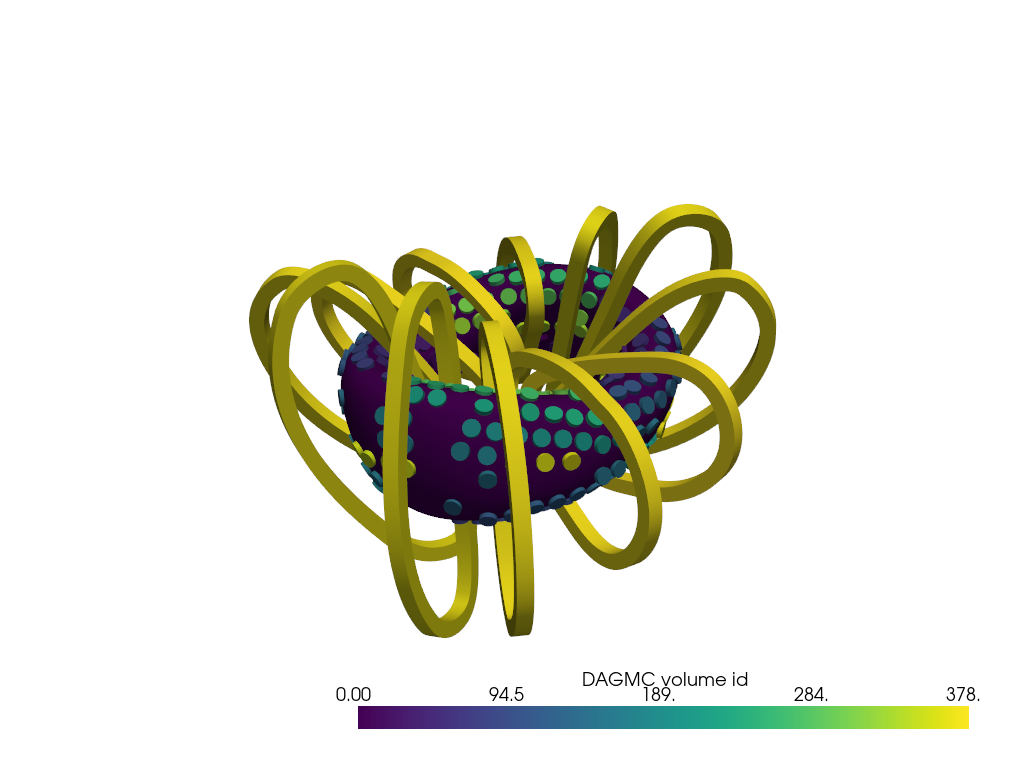

In [2]:
# plot the dagmc model
model = sv.import_dagmc('./model_thea/dagmc.h5m')

plot = pv.Plotter()
plot.add_mesh(model, scalars='DAGMC volume id')
plot.show(jupyter_backend='static')

## Add MaterialFilter tally data

In [3]:
with openmc.StatePoint('./model_thea/statepoint.200.h5') as sp:
    tally_df = sp.get_tally(name='heating material').get_pandas_dataframe()
display(tally_df)
materials = openmc.Materials.from_xml('./model_thea/materials.xml')
mesh = sv.add_material_tally_data(model, tally_df, materials)
display(mesh[:10])
display(mesh[0])

,material,nuclide,score,mean,std. dev.
0,15,total,heating,5.110323e+05,208.932256
1,16,total,heating,6.519837e+06,1104.523432
2,17,total,heating,9.020382e+03,40.508365
3,18,total,heating,1.049863e+02,4.917984
4,19,total,heating,1.157098e+02,5.083574
...,...,...,...,...,...
374,389,total,heating,3.321130e+03,37.818119
375,390,total,heating,3.330489e+03,40.308755
376,391,total,heating,3.282986e+03,34.637304
377,392,total,heating,3.284197e+03,36.428198


MultiBlock (0x7ff9718ac880)
  N Blocks:   10
  X Bounds:   -4.468e+02, 4.468e+02
  Y Bounds:   -3.895e+02, 3.895e+02
  Z Bounds:   -1.742e+02, 1.742e+02

PolyData (0x7ff9ab038640)
  N Cells:    178646
  N Points:   535938
  N Strips:   0
  X Bounds:   -3.988e+02, 3.988e+02
  Y Bounds:   -3.415e+02, 3.415e+02
  Z Bounds:   -1.262e+02, 1.262e+02
  N Arrays:   7

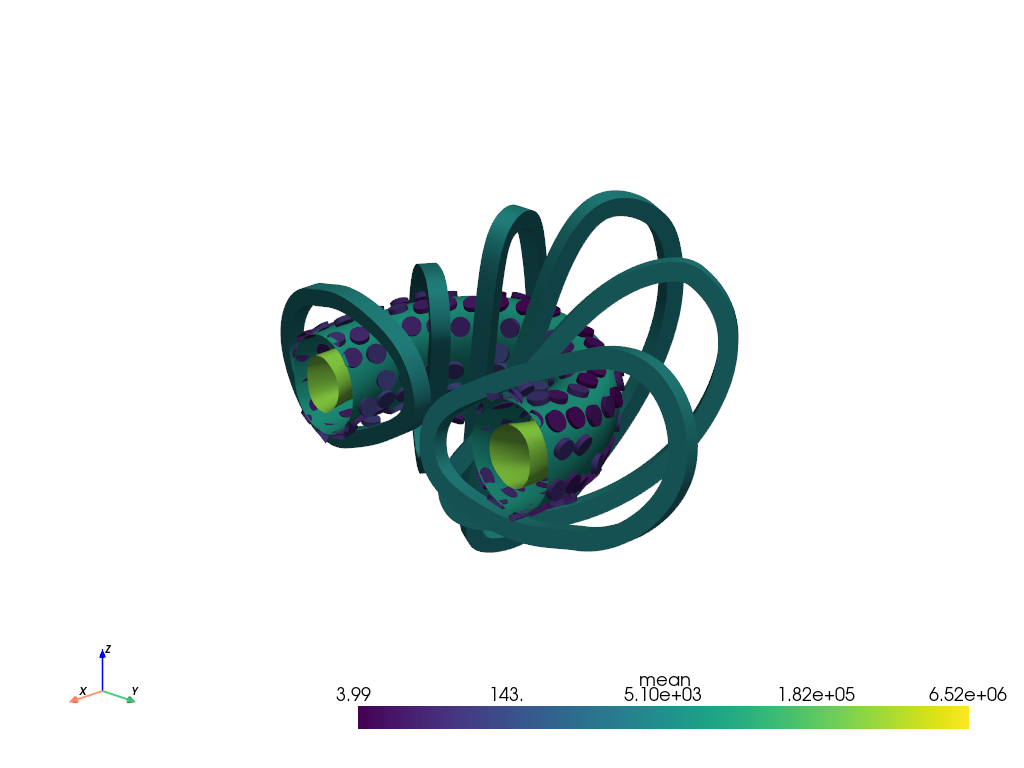

In [4]:
mesh.clip().plot(scalars='mean', log_scale=True, jupyter_backend='static', cpos=[1,1,0.5])

## Plot a subset of components

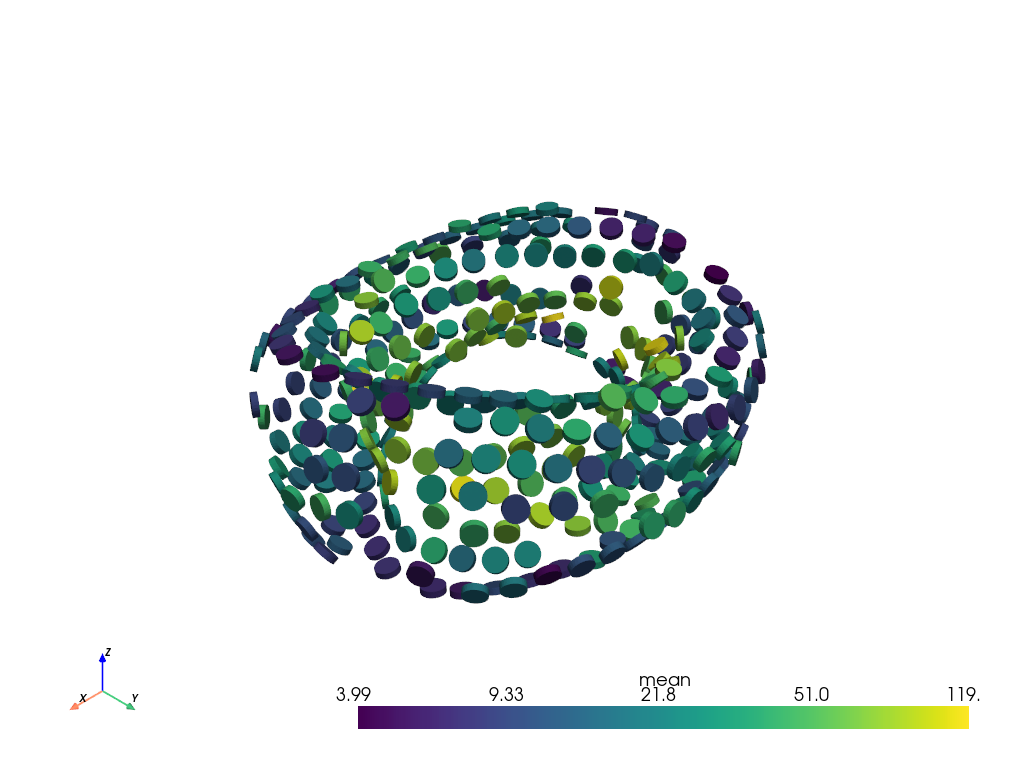

In [5]:
shaping_coils = pv.MultiBlock()
for block in mesh:
    if "shaping_coil_" in block['material name']:
        shaping_coils.append(block)
shaping_coils.plot(scalars='mean', log_scale=True, jupyter_backend='static', cpos=[1,1,1])